### pyAPES_MLM: Multi-layer soil-vegetation-atmosphere transfer model

Demo how to:
1. Set-up the model
1. Run the model
1. Retrieve the results using xarray

In [1]:
# setting path
import sys
import os

from dotenv import load_dotenv
load_dotenv()
pyAPES_main_folder = os.getenv('pyAPES_main_folder')
sys.path.append(pyAPES_main_folder)
os.chdir(pyAPES_main_folder)

### Import modules

In [2]:
from pyAPES.utils.iotools import read_results
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

resultfile = 'results/202605291331_degero_snow.nc'
# read simulation restuls to xarray dataset
results = read_results(resultfile)

In [3]:
met = f'{pyAPES_main_folder}/forcing/Degero/Degero_meteo_2021-2023.dat'
flux = f'{pyAPES_main_folder}/forcing/SE-Deg/SE-Deg_EC_2021-2023.dat'
start = pd.to_datetime(str(results['date'][0].values))
end = pd.to_datetime(str(results['date'][-1].values))
meteo = pd.read_csv(met, sep=';', index_col=0, parse_dates=True)
fluxes = pd.read_csv(flux, sep=';', index_col=0, parse_dates=True)
meteo = meteo[start:end]
meteo['WTD_c'] = meteo['WTD']
meteo.loc[meteo['WTD_c'] < 0, 'WTD_c'] = 0.0
meteo['D_SNOW'] = meteo['D_SNOW']/100
meteo.loc[meteo['D_SNOW'] > 1., 'D_SNOW'] = np.nan
meteo = meteo.resample('D').mean()

binned = pd.cut(meteo['D_SNOW'], bins=100)
most_frequent_bin = binned.value_counts().idxmax()
baseval1 = round((most_frequent_bin.left + most_frequent_bin.right) / 2, 2)
baseval2 = round(meteo['D_SNOW'].median(), 2)
baseval2 = 0.05

meteo['D_SNOW_C'] = meteo['D_SNOW'] - baseval2
meteo.loc[meteo['D_SNOW_C'] < 0., 'D_SNOW_C'] = 0.
meteo.index.name = 'date'

/opt/miniconda3/envs/pyapes/lib/python3.14/site-packages/pandas/plotting/_matplotlib/core.py:997: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


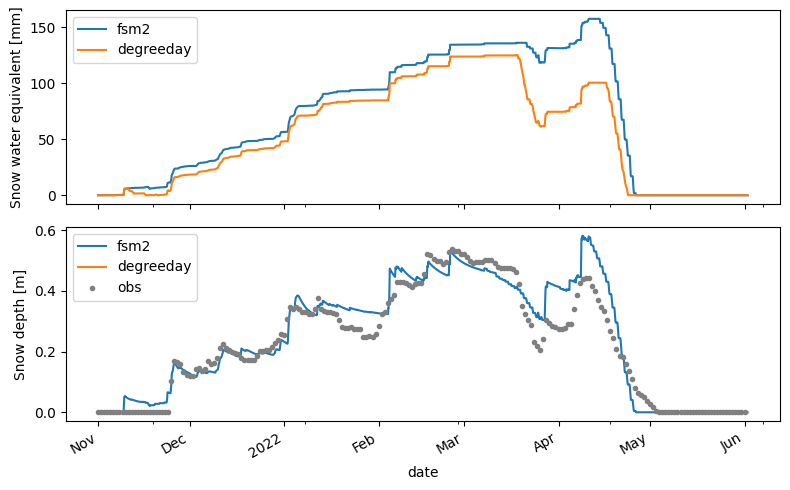

In [4]:
plot_start = '2021-11-01'
plot_end = '2022-06-01'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
simulations = {0: 'fsm2', 1: 'degreeday'}

for simu, label in simulations.items():
    results['ffloor_snow_water_equivalent'].sel(simulation=simu).sel(date=slice(plot_start, plot_end)).plot(ax=ax1, label=label)
ax1.legend(loc='upper left')
ax1.set_ylabel('Snow water equivalent [mm]')
ax1.set_title('')

for simu, label in simulations.items():
    results['ffloor_snow_depth'].sel(simulation=simu).sel(date=slice(plot_start, plot_end)).plot(ax=ax2, label=label)
meteo['D_SNOW_C'].resample('D').mean()[plot_start:plot_end].plot(ax=ax2, color='gray', marker='.', linestyle='none', label='obs')
ax2.set_ylabel('Snow depth [m]')
ax2.legend(loc='upper left')
ax2.set_title('')

plt.tight_layout()


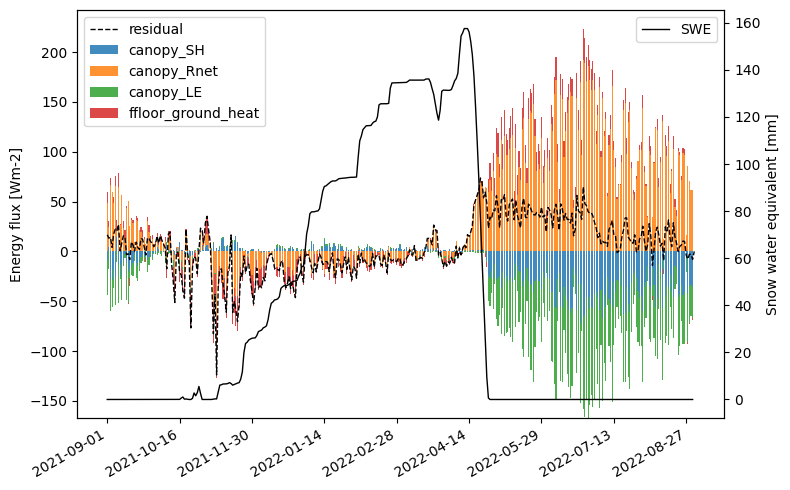

In [9]:
#Time window to plot
%matplotlib inline

plot_start = '2021-09-01'
plot_end = '2022-09-01'
simulation = 0
flux_cols = ['canopy_SH',
            'canopy_Rnet',
            'canopy_LE',
            'ffloor_ground_heat'
            ]
#flux_cols = ['ffloor_sensible_heat',
#            'ffloor_net_radiation',
#            'ffloor_latent_heat',
#            'ffloor_ground_heat'
#            ]
flux_cols_extra = ['canopy_SWnet', 'canopy_LWnet']

results_flux = results[flux_cols + flux_cols_extra].sel(simulation=simulation).sel(date=slice(plot_start, plot_end))

results_flux['canopy_SH'] *= -1
results_flux['canopy_LE'] *= -1

#Daily mean fluxes
results_flux = results_flux.resample(date='1D').mean().to_dataframe()[flux_cols + flux_cols_extra]
swe = results['ffloor_snow_water_equivalent'].sel(simulation=simulation).sel(date=slice(plot_start, plot_end)).resample(date='1D').mean().to_dataframe()['ffloor_snow_water_equivalent']

results_pos = results_flux[flux_cols].clip(lower=0)
results_neg = results_flux[flux_cols].clip(upper=0)

pos = results_pos[flux_cols]
neg = results_neg[flux_cols]

idx = pos.index.union(neg.index)
pos = pos.reindex(idx).fillna(0.0)
neg = neg.reindex(idx).fillna(0.0)

residual = results_flux[flux_cols].sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(idx))
width = 0.7

pos_bottom = np.zeros(len(idx))
neg_bottom = np.zeros(len(idx))

cycle = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
colors = {c: cycle[i % len(cycle)] for i, c in enumerate(flux_cols)}

for col in flux_cols:
    y = pos[col].to_numpy()
    ax.bar(x, y, bottom=pos_bottom, width=width, alpha=0.85, color=colors[col], label=col)
    pos_bottom += y

for col in flux_cols:
    y = neg[col].to_numpy()
    ax.bar(x, y, bottom=neg_bottom, width=width, alpha=0.85, color=colors[col])
    neg_bottom += y

ax.plot(x, residual.reindex(idx).to_numpy(), color='black', linewidth=1.0, linestyle='--', label='residual')

ax.set_ylabel("Energy flux [Wm-2]")
ax.legend(loc="upper left")

ax2 = ax.twinx()
ax2.plot(x, swe.to_numpy(), linewidth=1.0, color='black', linestyle='-', label="SWE")
ax2.set_ylabel("Snow water equivalent [mm]")
ax2.legend(loc="upper right")

tick_step = max(1, len(idx) // 8)
ax.set_xticks(x[::tick_step])
ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in idx[::tick_step]], rotation=30, ha="right")

plt.tight_layout()
#filename = f'/Users/jpnousu/Library/CloudStorage/OneDrive-Luonnonvarakeskus/pyAPES_figs/ebal_{snowmod}_coupled_2026.png'
#plt.savefig(filename, dpi=300, bbox_inches="tight")


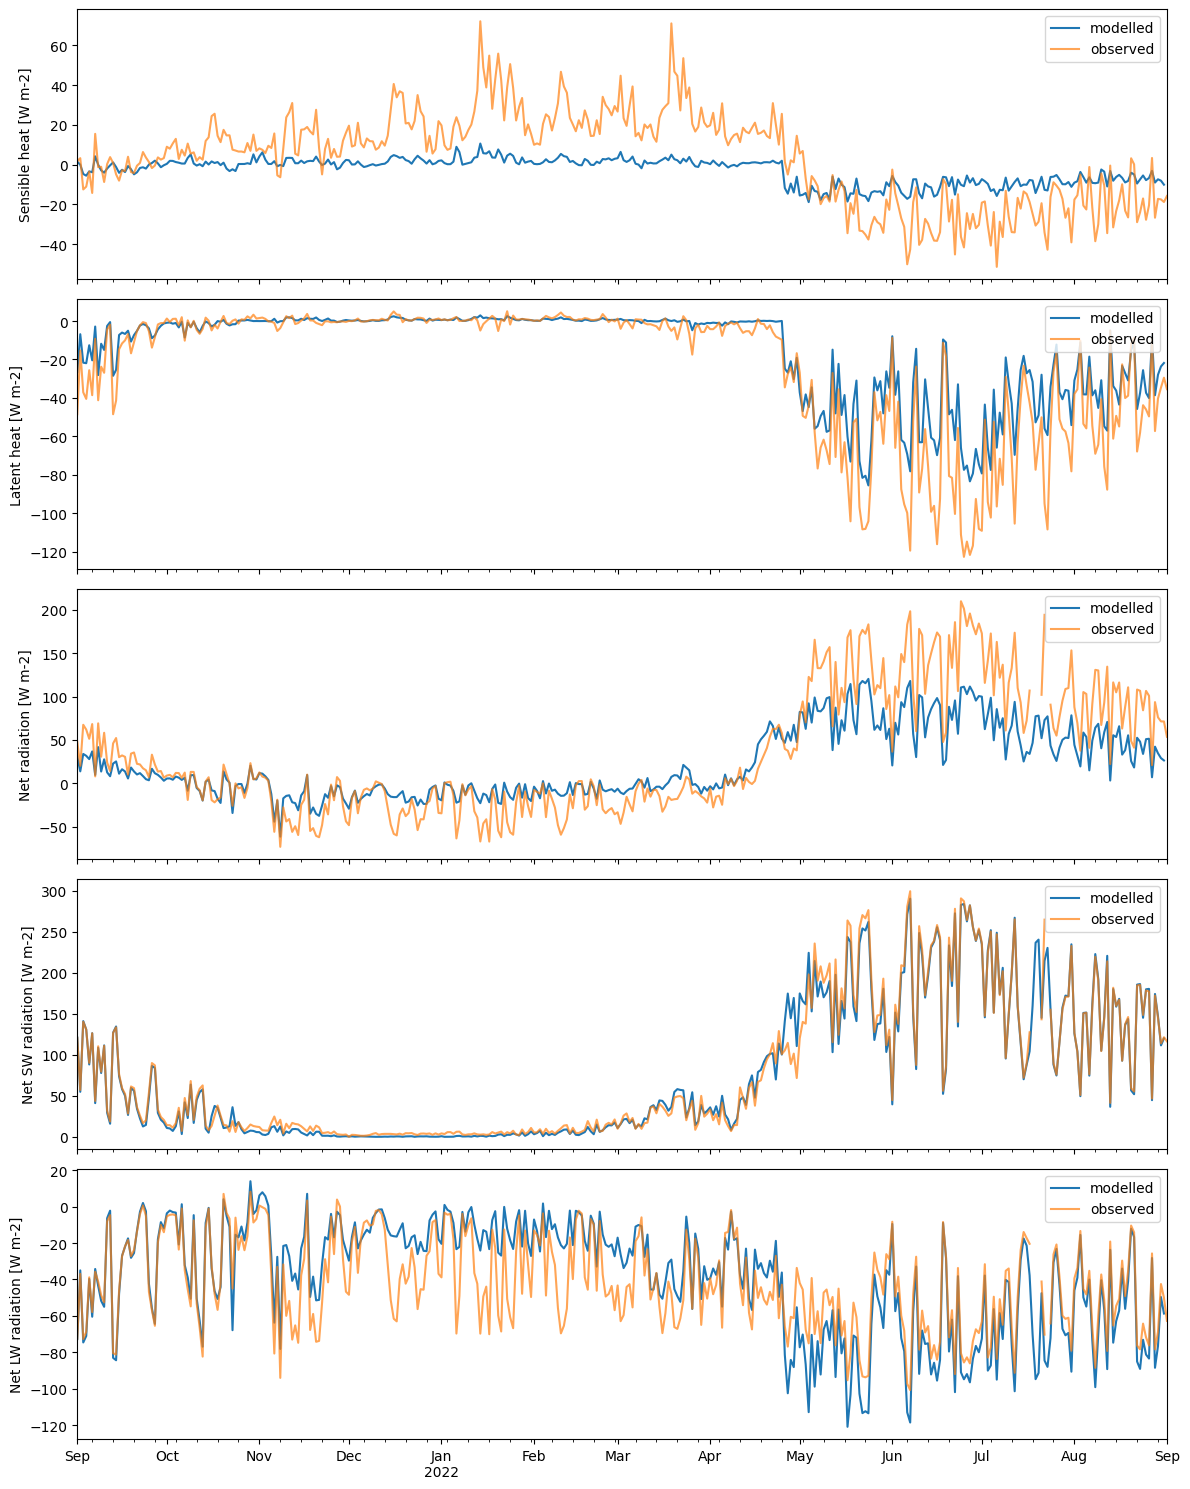

In [ ]:
# Resample observed fluxes to daily and slice to match modelled index
fluxes_daily = fluxes.resample('D').mean().loc[results_flux.index[0]:results_flux.index[-1]]

# Compute observed radiation components
fluxes_daily['Rnet_obs']  = (fluxes_daily['SW_IN_F'] - fluxes_daily['SW_OUT'] +
                              fluxes_daily['LW_IN_F'] - fluxes_daily['LW_OUT'])
fluxes_daily['SWnet_obs'] = fluxes_daily['SW_IN_F'] - fluxes_daily['SW_OUT']
fluxes_daily['LWnet_obs'] = fluxes_daily['LW_IN_F'] - fluxes_daily['LW_OUT']

# Fix sign convention for observed H and LE
fluxes_daily['H_F_MDS']  *= -1
fluxes_daily['LE_F_MDS'] *= -1

# Pairs: (modelled column, observed column, y-axis label)
pairs = [
    ('canopy_SH',    'H_F_MDS',   'Sensible heat [W m-2]'),
    ('canopy_LE',    'LE_F_MDS',  'Latent heat [W m-2]'),
    ('canopy_Rnet',  'Rnet_obs',  'Net radiation [W m-2]'),
    ('canopy_SWnet', 'SWnet_obs', 'Net SW radiation [W m-2]'),
    ('canopy_LWnet', 'LWnet_obs', 'Net LW radiation [W m-2]'),
]
#pairs = [
#    ('ffloor_sensible_heat',    'H_F_MDS',   'Sensible heat [W m-2]'),
#    ('ffloor_latent_heat',    'LE_F_MDS',  'Latent heat [W m-2]'),
#    ('ffloor_net_radiation',  'Rnet_obs',  'Net radiation [W m-2]'),
#    ('canopy_SWnet', 'SWnet_obs', 'Net SW radiation [W m-2]'),
#    ('canopy_LWnet', 'LWnet_obs', 'Net LW radiation [W m-2]'),
#]

n = len(pairs)
fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=True)

for ax, (mod_col, obs_col, ylabel) in zip(axes, pairs):
    results_flux[mod_col].plot(ax=ax, label='modelled')
    fluxes_daily[obs_col].plot(ax=ax, label='observed', alpha=0.7)
    ax.set_ylabel(ylabel)
    ax.set_title('')
    ax.set_xlabel('')
    ax.legend(loc='upper right')

plt.tight_layout()
